
# Customer Churn Prediction (SaaS) — End-to-End Notebook

This notebook walks through a clear, reproducible pipeline to build and evaluate a **customer churn prediction** model for a SaaS product.

**What you'll see:**  
1) Load & preview data  
2) Check class balance and missing values  
3) Split data (train/test)  
4) Preprocess (impute, scale, one-hot encode)  
5) Train a baseline model (Logistic Regression)  
6) Evaluate with common metrics + curves  
7) Interpret results & print a friendly summary


In [2]:

# 1) Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, roc_curve, precision_recall_curve, average_precision_score,
                             confusion_matrix, accuracy_score, precision_score, recall_score, f1_score)

# Settings
pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (6,4)  # compact, readable


In [3]:

# 2) Load & preview data
path = "customer_churn_dataset-testing-master.csv"  # update if needed
df = pd.read_csv(path)

print("Shape:", df.shape)
display(df.head(10))
print("\nColumns:", list(df.columns))
print("\nMissing values per column:\n", df.isna().sum())


Shape: (64374, 12)


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0
5,6,30,Male,41,14,10,10,Premium,Monthly,500,29,0
6,7,47,Female,37,15,9,28,Basic,Quarterly,574,14,1
7,8,54,Female,36,11,0,18,Standard,Monthly,323,16,0
8,9,36,Male,20,5,10,8,Basic,Monthly,687,8,0
9,10,65,Male,8,4,2,23,Basic,Annual,995,10,0



Columns: ['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction', 'Churn']

Missing values per column:
 CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64


In [4]:

# 3) Quick EDA: target balance & simple stats
target_col = "Churn"
print("Target value counts:")
print(df[target_col].value_counts(dropna=False))
print("\nTarget ratio (churn rate):", df[target_col].mean().round(4))
display(df.describe(include="all"))


Target value counts:
Churn
0    33881
1    30493
Name: count, dtype: int64

Target ratio (churn rate): 0.4737


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
count,64374.000000,64374.000000,64374,64374.000000,64374.000000,64374.000000,64374.000000,64374,64374,64374.000000,64374.000000,64374.000000
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,NaN,NaN,NaN
top,NaN,NaN,Female,NaN,NaN,NaN,NaN,Standard,Monthly,NaN,NaN,NaN
freq,NaN,NaN,34353,NaN,NaN,NaN,NaN,21502,22130,NaN,NaN,NaN
mean,32187.500000,41.970982,NaN,31.994827,15.080234,5.400690,17.133952,NaN,NaN,541.023379,15.498850,0.473685
std,18583.317451,13.924911,NaN,17.098234,8.816470,3.114005,8.852211,NaN,NaN,260.874809,8.638436,0.499311
min,1.000000,18.000000,NaN,1.000000,1.000000,0.000000,0.000000,NaN,NaN,100.000000,1.000000,0.000000
25%,16094.250000,30.000000,NaN,18.000000,7.000000,3.000000,10.000000,NaN,NaN,313.000000,8.000000,0.000000
50%,32187.500000,42.000000,NaN,33.000000,15.000000,6.000000,19.000000,NaN,NaN,534.000000,15.000000,0.000000
75%,48280.750000,54.000000,NaN,47.000000,23.000000,8.000000,25.000000,NaN,NaN,768.000000,23.000000,1.000000


In [5]:

# 4) Identify feature groups
id_cols = ["CustomerID"]
categorical_cols = ["Gender", "Subscription Type", "Contract Length"]
numeric_cols = [c for c in df.columns if c not in id_cols + categorical_cols + [target_col]]

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)


Categorical columns: ['Gender', 'Subscription Type', 'Contract Length']
Numeric columns: ['Age', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Total Spend', 'Last Interaction']


In [6]:

# 5) Train-test split
X = df.drop(columns=[target_col] + id_cols)
y = df[target_col].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)


Train shape: (51499, 10)  Test shape: (12875, 10)


In [7]:

# 6) Preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, [c for c in X.columns if c in numeric_cols]),
        ("cat", categorical_transformer, [c for c in X.columns if c in categorical_cols])
    ]
)

print("Preprocessing ready.")


Preprocessing ready.


In [8]:

# 7) Train baseline model (Logistic Regression)
log_reg = LogisticRegression(max_iter=500)
pipe = Pipeline(steps=[("preprocess", preprocess), ("model", log_reg)])
pipe.fit(X_train, y_train)
print("Model trained.")


Model trained.


In [9]:

# 8) Evaluate model
y_proba = pipe.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)

roc_auc = roc_auc_score(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"ROC AUC: {roc_auc:.4f}")
print(f"PR AUC (Average Precision): {pr_auc:.4f}")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1-score: {f1:.4f}")
print("\nConfusion Matrix (rows: actual 0/1, cols: predicted 0/1):\n", cm)


ROC AUC: 0.9030
PR AUC (Average Precision): 0.8932
Accuracy: 0.8270
Precision: 0.8137
Recall: 0.8234
F1-score: 0.8185

Confusion Matrix (rows: actual 0/1, cols: predicted 0/1):
 [[5626 1150]
 [1077 5022]]


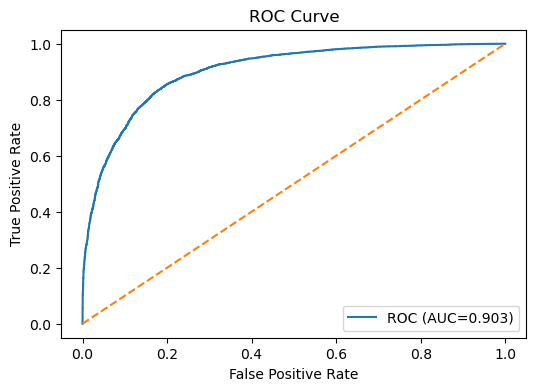

In [10]:

# 9) Plot ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure()
plt.plot(fpr, tpr, label=f"ROC (AUC={roc_auc:.3f})")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()


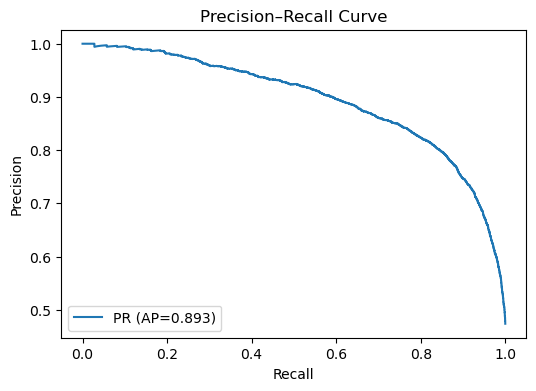

In [11]:

# 10) Plot Precision–Recall curve
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba)
plt.figure()
plt.plot(recall_vals, precision_vals, label=f"PR (AP={pr_auc:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend(loc="lower left")
plt.show()


In [12]:

# 11) Simple interpretability: show largest-magnitude coefficients
# Get feature names after preprocessing
ohe = pipe.named_steps["preprocess"].named_transformers_["cat"].named_steps["onehot"]
cat_features = ohe.get_feature_names_out(categorical_cols)
feature_names = np.concatenate([numeric_cols, cat_features])

coefs = pipe.named_steps["model"].coef_.ravel()
coef_df = pd.DataFrame({"feature": feature_names, "coef": coefs})
coef_df["abs_coef"] = coef_df["coef"].abs()
top_coef = coef_df.sort_values("abs_coef", ascending=False).head(15).drop(columns="abs_coef")
display(top_coef)


,feature,coef
4,Payment Delay,1.893247
3,Support Calls,1.035705
8,Gender_Male,-0.658893
1,Tenure,0.598092
2,Usage Frequency,-0.523725
7,Gender_Female,0.483749
14,Contract Length_Quarterly,-0.283710
0,Age,0.271749
5,Total Spend,-0.258662
13,Contract Length_Monthly,0.223234


In [13]:

# 12) Friendly business summary
tn, fp, fn, tp = cm.ravel()
churn_rate = y.mean()

print("==== Business-Friendly Summary ====")
print(f"- We trained a simple, explainable model (Logistic Regression) to predict churn.")
print(f"- Test ROC AUC: {roc_auc:.3f} (higher is better; 1.0 is perfect).")
print(f"- Precision: {prec:.3f}, Recall: {rec:.3f}, F1: {f1:.3f}.")
print(f"- Confusion matrix: TN={tn}, FP={fp}, FN={fn}, TP={tp}.")
print(f"- Approx. churn rate in data: {churn_rate:.3f}.")
print("\nHow to use this:")
print("- Customers with higher predicted churn probability can be prioritized for retention actions (discounts, outreach).")
print("- The top coefficients indicate which factors correlate most with churn risk (positive -> higher churn risk).")


==== Business-Friendly Summary ====
- We trained a simple, explainable model (Logistic Regression) to predict churn.
- Test ROC AUC: 0.903 (higher is better; 1.0 is perfect).
- Precision: 0.814, Recall: 0.823, F1: 0.819.
- Confusion matrix: TN=5626, FP=1150, FN=1077, TP=5022.
- Approx. churn rate in data: 0.474.

How to use this:
- Customers with higher predicted churn probability can be prioritized for retention actions (discounts, outreach).
- The top coefficients indicate which factors correlate most with churn risk (positive -> higher churn risk).
